<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
#data libraries
import pandas as pd
import numpy as np

In [ ]:
#visualation libraries
import seaborn as sns

In [ ]:
#ml libraries
from sklearn.model_selection import train_test_split, KFold,RandomizedSearchCV,cross_val_score,GridSearchCV
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier

from sklearn import metrics

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier


# **Loading the dataset**

In [ ]:
initial_data = pd.read_csv("EasyVisa.csv")
initial_data.head(10)

# **Overview of the Dataset**

* Observations

* Sanity checks

In [ ]:
rows,cols = initial_data.shape
print(f"There are {rows} rows and {cols} columns")

In [ ]:
initial_data.info()
# We have a lot of object types. Lets get those into strings for now.

In [ ]:
initial_data.describe()

In [ ]:
visa_data = initial_data.copy()

# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**

What is the distribution of visa case statuses (certified vs. denied)?


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

In [ ]:
sns.pairplot(data=visa_data, diag_kind="kde")

In [ ]:
visa_data.columns

In [ ]:
sns.histplot(data=visa_data,y="continent")
# Large majority of cases are from Asia continent.

<Axes: xlabel='Count', ylabel='education_of_employee'>

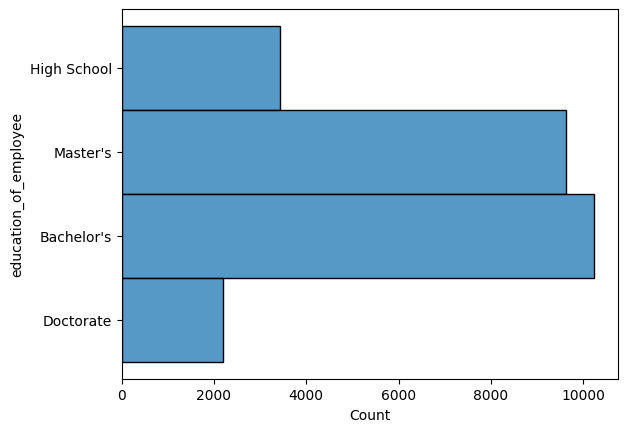

In [141]:
sns.histplot(data=visa_data,y="education_of_employee")
# Most cases have at least a college eductation.

<Axes: xlabel='has_job_experience', ylabel='Count'>

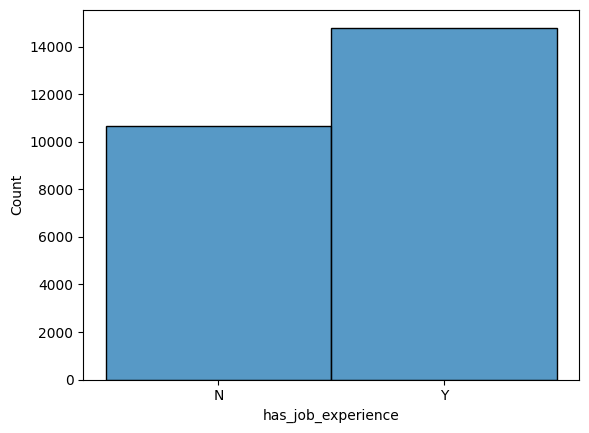

In [142]:
sns.histplot(data=visa_data,x="has_job_experience")

<Axes: xlabel='has_job_experience', ylabel='count'>

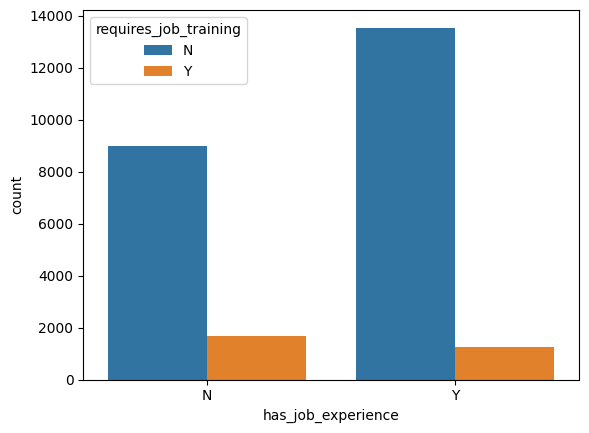

In [143]:
sns.countplot(
    data=visa_data,
    x="has_job_experience",
    hue="requires_job_training"
)
# Most cases regardless of job experience do not require job training.

<Axes: xlabel='education_of_employee', ylabel='count'>

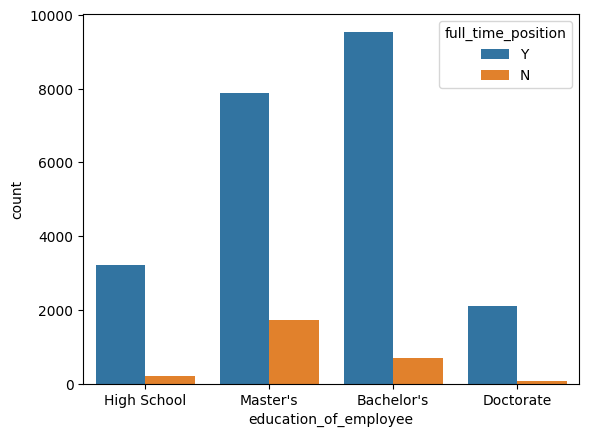

In [144]:
sns.countplot(
    data=visa_data,
    x="education_of_employee",
    hue="full_time_position"
)

<Axes: xlabel='education_of_employee', ylabel='Count'>

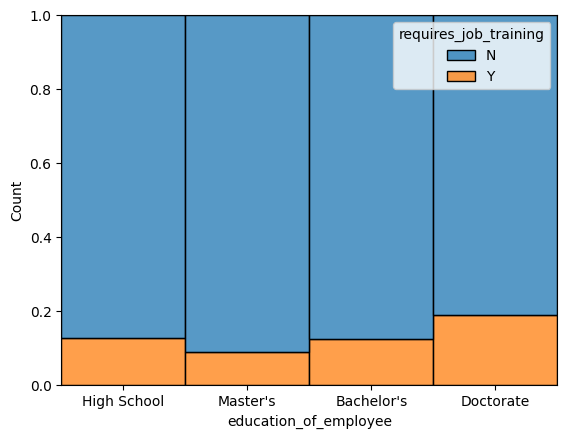

In [145]:
sns.histplot(
    data=visa_data,
    x="education_of_employee",
    hue="requires_job_training",
    multiple="fill"
)
# Roughly same percentage of cases regardless of eductation require job training.

<Axes: xlabel='region_of_employment', ylabel='count'>

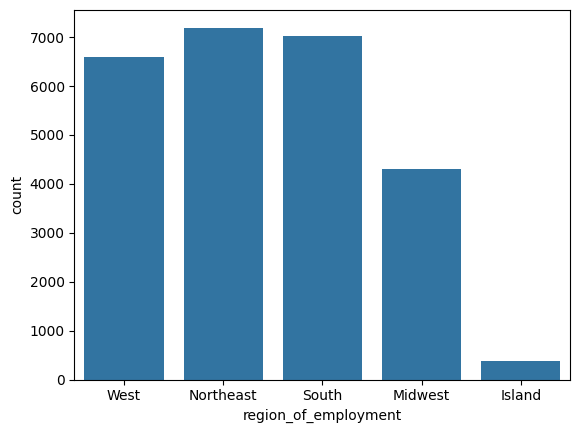

In [146]:
sns.countplot(data=visa_data,x="region_of_employment")

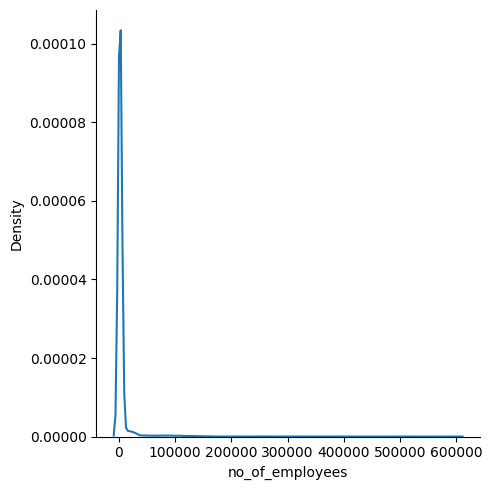

In [147]:
sns.displot(data=visa_data,x="no_of_employees",kind="kde")
# right skewed

<Axes: xlabel='prevailing_wage'>

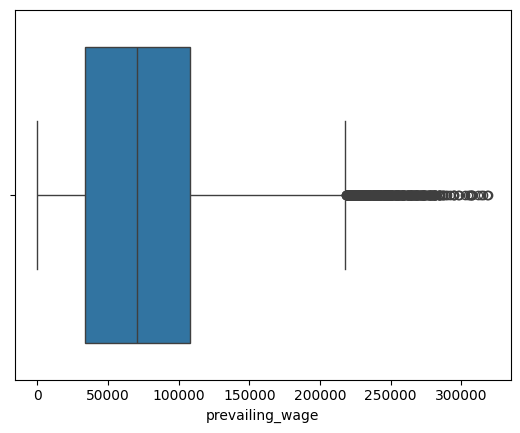

In [148]:

sns.boxplot(data=visa_data, x="prevailing_wage")
# Most wages between 40 - 110K

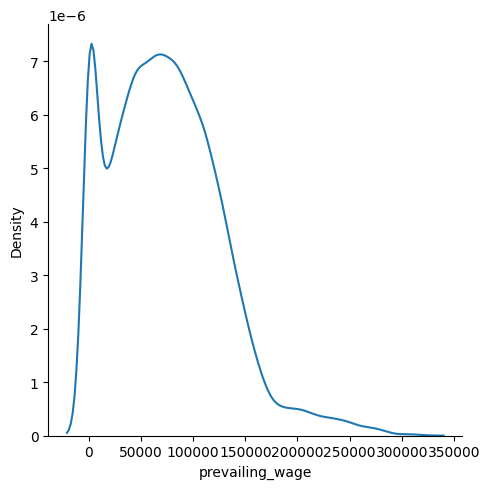

In [149]:
sns.displot(data=visa_data,x="prevailing_wage",kind="kde")
# right skewed

<Axes: >

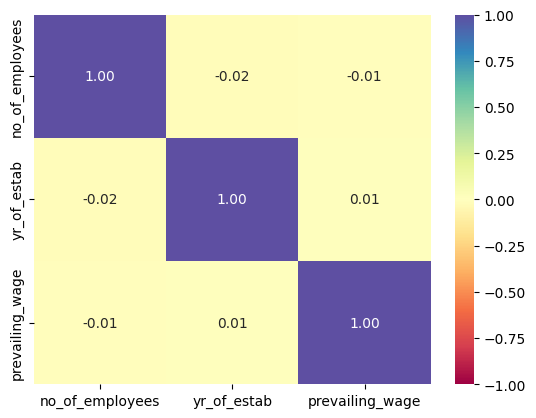

In [150]:
num_cols = visa_data.select_dtypes(include=np.number).columns.tolist()
sns.heatmap(
    visa_data[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
# Really no correlations found in numerical cols

percent certified cases 66.78963893249608%
percent denied cases 33.210361067503925%


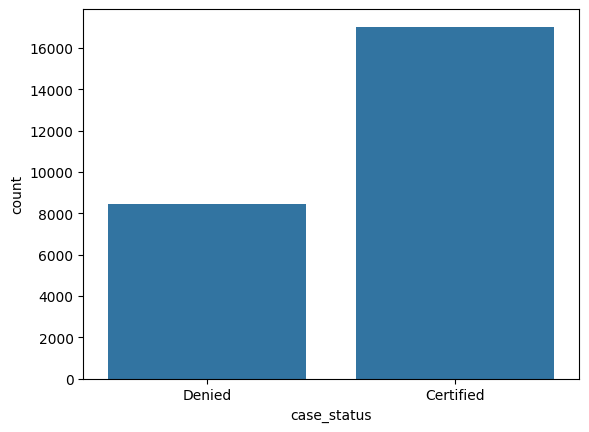

In [151]:
# Lets look at distribution of case status
# About 1/3 of cases were denied.
# What is the distribution of visa case statuses (certified vs. denied)?
sns.countplot(data=visa_data,x="case_status")
visa_data["case_status"].value_counts()
total = visa_data.shape[0]
cert = visa_data[visa_data["case_status"]=="Certified"].shape[0]
denied = visa_data[visa_data["case_status"]=="Denied"].shape[0]
perc_cert = (cert/total)*100
perc_denied = (denied/total)*100
print(f"percent certified cases {perc_cert}%")
print(f"percent denied cases {perc_denied}%")

<Axes: xlabel='education_of_employee', ylabel='Count'>

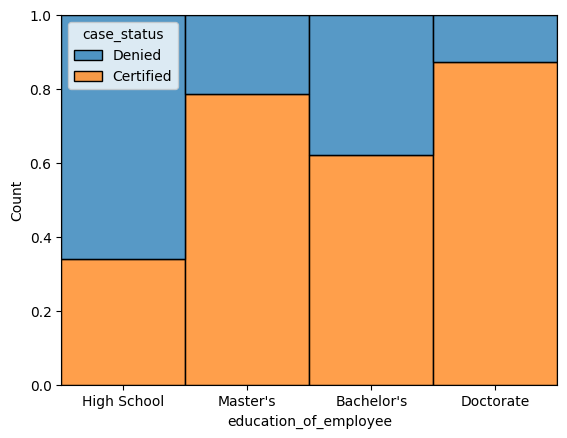

In [152]:
# How does the education level of employees impact visa approval rates?
sns.histplot(
    data=visa_data,
    x="education_of_employee",
    hue="case_status",
    multiple="fill"
)
# Having a masters or doctorate makes you highly like 80% to be certified. Bachelor is 60%. Highschool is least likely to be certified.

<Axes: xlabel='has_job_experience', ylabel='Count'>

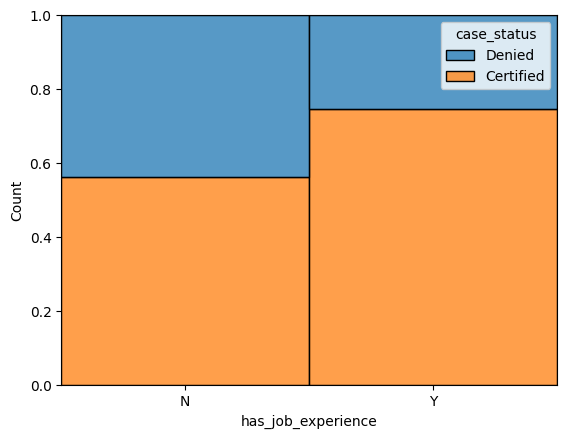

In [153]:
# Is there a significant difference in visa approval rates between employees with and without prior job experience?
sns.histplot(
    data=visa_data,
    x="has_job_experience",
    hue="case_status",
    multiple="fill"
)

# I would not say that there is a signifigant difference in approval rates for employees with prior job experience but it does improve their chances having an approval.

<Axes: xlabel='case_status', ylabel='prevailing_wage'>

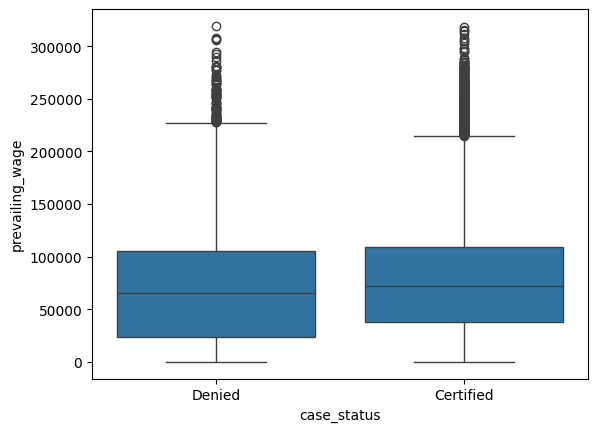

In [154]:
# How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
sns.boxplot(data=visa_data, x="case_status", y="prevailing_wage")
# Higher wages do not necessarily lead to higher chances of approval.

<Axes: xlabel='region_of_employment', ylabel='Count'>

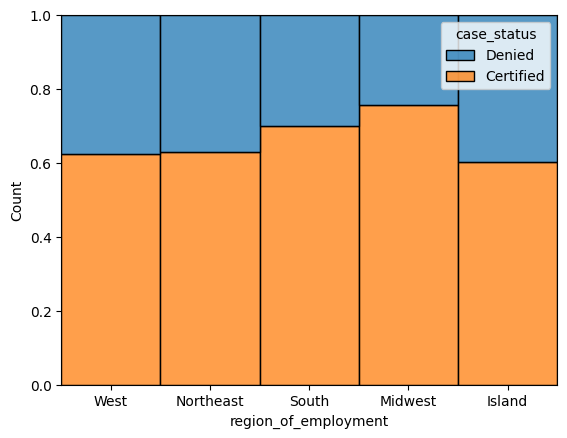

In [155]:
# Do certain regions in the US have higher visa approval rates compared to others?
sns.histplot(
    data=visa_data,
    x="region_of_employment",
    hue="case_status",
    multiple="fill"
)
# It does not really appear that any region has a high approval rate.

<Axes: xlabel='no_of_employees', ylabel='Density'>

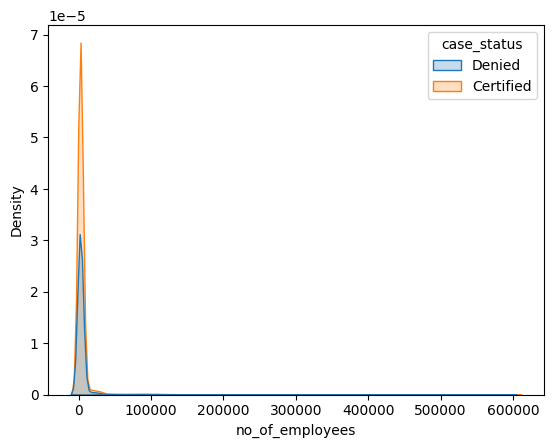

In [156]:
# How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
# sns.boxplot(data=visa_data, x="case_status", y="no_of_employees")
sns.kdeplot(data=visa_data, x="no_of_employees", hue="case_status", fill=True)
# It appears that smaller companies actually have a higher approval rate.

<Axes: xlabel='continent', ylabel='Count'>

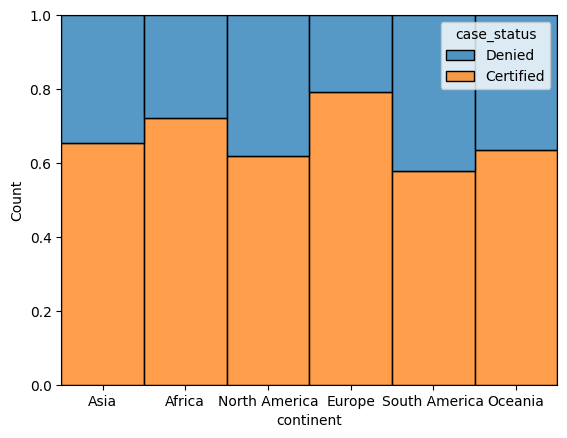

In [157]:
# Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?
sns.histplot(
    data=visa_data,
    x="continent",
    hue="case_status",
    multiple="fill"
)
# There appears to be a higher rate of approval in Europe and Africa and arround 60% in the other continenets.

# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [158]:
# No nulls to impute
visa_data.isna().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


In [159]:
visa_data.duplicated().sum()
# No dupes good job data engineer.

np.int64(0)

In [160]:
column_names = visa_data.columns
for col in column_names:
  if visa_data[col].dtype == 'object':
    visa_data[col] = visa_data[col].astype('string')

visa_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  string 
 1   continent              25480 non-null  string 
 2   education_of_employee  25480 non-null  string 
 3   has_job_experience     25480 non-null  string 
 4   requires_job_training  25480 non-null  string 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  string 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  string 
 10  full_time_position     25480 non-null  string 
 11  case_status            25480 non-null  string 
dtypes: float64(1), int64(2), string(9)
memory usage: 2.3 MB


In [161]:
if "case_id" in visa_data.columns:
  visa_data = visa_data.drop(columns=["case_id"])
visa_data.head()
# We do not need unique identifiers.

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [162]:
dummy_cols = ["continent","education_of_employee","region_of_employment","unit_of_wage"]
visa_data = pd.get_dummies(data=visa_data,columns=dummy_cols,dtype=int)
visa_data



,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,prevailing_wage,full_time_position,case_status,continent_Africa,continent_Asia,continent_Europe,...,education_of_employee_Master's,region_of_employment_Island,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Hour,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year
0,N,N,14513,2007,592.2029,Y,Denied,0,1,0,...,0,0,0,0,0,1,1,0,0,0
1,Y,N,2412,2002,83425.6500,Y,Certified,0,1,0,...,1,0,0,1,0,0,0,0,0,1
2,N,Y,44444,2008,122996.8600,Y,Denied,0,1,0,...,0,0,0,0,0,1,0,0,0,1
3,N,N,98,1897,83434.0300,Y,Denied,0,1,0,...,0,0,0,0,0,1,0,0,0,1
4,Y,N,1082,2005,149907.3900,Y,Certified,1,0,0,...,1,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,Y,Y,2601,2008,77092.5700,Y,Certified,0,1,0,...,0,0,0,0,1,0,0,0,0,1
25476,Y,N,3274,2006,279174.7900,Y,Certified,0,1,0,...,0,0,0,1,0,0,0,0,0,1
25477,Y,N,1121,1910,146298.8500,N,Certified,0,1,0,...,1,0,0,0,1,0,0,0,0,1
25478,Y,Y,1918,1887,86154.7700,Y,Certified,0,1,0,...,1,0,0,0,0,1,0,0,0,1


In [163]:
# Yes no cols to int
cols = ["requires_job_training", "has_job_experience", "full_time_position"]

visa_data[cols] = visa_data[cols].apply(lambda x: x.map({"Y": 1, "N": 0}))

In [164]:
# certified denied to int
visa_data["case_status"] = visa_data["case_status"].map({
    "Certified": 1,
    "Denied": 0
})

In [165]:
visa_data

,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,prevailing_wage,full_time_position,case_status,continent_Africa,continent_Asia,continent_Europe,...,education_of_employee_Master's,region_of_employment_Island,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Hour,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year
0,0,0,14513,2007,592.2029,1,0,0,1,0,...,0,0,0,0,0,1,1,0,0,0
1,1,0,2412,2002,83425.6500,1,1,0,1,0,...,1,0,0,1,0,0,0,0,0,1
2,0,1,44444,2008,122996.8600,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,1
3,0,0,98,1897,83434.0300,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,1
4,1,0,1082,2005,149907.3900,1,1,1,0,0,...,1,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,1,1,2601,2008,77092.5700,1,1,0,1,0,...,0,0,0,0,1,0,0,0,0,1
25476,1,0,3274,2006,279174.7900,1,1,0,1,0,...,0,0,0,1,0,0,0,0,0,1
25477,1,0,1121,1910,146298.8500,0,1,0,1,0,...,1,0,0,0,1,0,0,0,0,1
25478,1,1,1918,1887,86154.7700,1,1,0,1,0,...,1,0,0,0,0,1,0,0,0,1


In [166]:
model_data = visa_data.copy()

# **Model Building**

Attemping to use random forest as my classifier model.

In [167]:
def report(y, preds):
    print("Accuracy:", metrics.accuracy_score(y, preds))
    print("Precision:", metrics.precision_score(y, preds))
    print("Recall:", metrics.recall_score(y, preds))
    print("F1:", metrics.f1_score(y, preds))

In [168]:
def get_metrics_score(model,flag=True):
    '''
    model : classifier to predict values of X

    '''
    # defining an empty list to store train and test results
    score_list=[]

    #Predicting on train and tests
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    #Accuracy of the model
    train_acc = model.score(X_train,Y_train)
    test_acc = model.score(X_test,Y_test)

    #Recall of the model
    train_recall = metrics.recall_score(Y_test,pred_train)
    test_recall = metrics.recall_score(Y_test,pred_test)

    #Precision of the model
    train_precision = metrics.precision_score(Y_test,pred_train)
    test_precision = metrics.precision_score(Y_test,pred_test)

    score_list.extend((train_acc,test_acc,train_recall,test_recall,train_precision,test_precision))

    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True:
        print("Accuracy on training set : ",model.score(X_train,Y_test))
        print("Accuracy on test set : ",model.score(X_test,Y_test))
        print("Recall on training set : ",metrics.recall_score(Y_test,pred_train))
        print("Recall on test set : ",metrics.recall_score(Y_test,pred_test))
        print("Precision on training set : ",metrics.precision_score(Y_test,pred_train))
        print("Precision on test set : ",metrics.precision_score(Y_test,pred_test))

    return score_list # returning the list with train and test scores

In [169]:
def make_confusion_matrix(model,y_actual,labels=[1, 0]):
    import matplotlib.pyplot as plt
    '''
    model : classifier to predict values of X
    y_actual : ground truth

    '''
    y_predict = model.predict(X_test)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [170]:
from re import X
x = model_data.drop("case_status", axis=1)
y = model_data.pop("case_status")

In [171]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=.30, random_state=1,stratify=y)

Accuracy: 0.7314233385661957
Precision: 0.7892342683851402
Recall: 0.8156709108716944
F1: 0.8022348521337058


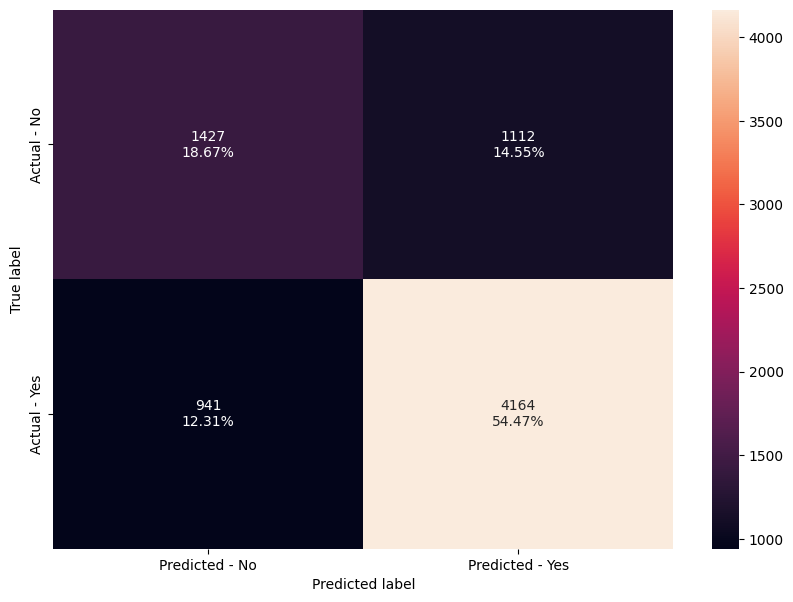

In [172]:
model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

model.fit(X_train, Y_train)

preds = model.predict(X_test)
report(Y_test,preds)
make_confusion_matrix(model,Y_test)
#  35 max_depth: 7

In [173]:
bagging_estimator=BaggingClassifier(estimator=model,random_state=1)
bagging_model = bagging_estimator.fit(X_train,Y_train)


In [174]:
preds = model.predict(X_test)
report(Y_test,preds)

Accuracy: 0.7314233385661957
Precision: 0.7892342683851402
Recall: 0.8156709108716944
F1: 0.8022348521337058


In [175]:
n_estimators = [3,5,10,15,20,25,30,35,40]
max_depths = [5,6,7,8,9,10,12,14]

In [ ]:
for n_estimator in n_estimators:
    for m_depth in max_depths:
        print("n_estimators:", n_estimator, "max_depth:", m_depth)

        model = RandomForestClassifier(
            n_estimators=n_estimator,
            max_depth=m_depth,
            random_state=42
        )

        # Fit on training data
        model.fit(X_train, Y_train)

        # Predict on test data
        preds = model.predict(X_test)
        report(Y_test,preds)

n_estimators: 3 max_depth: 5
Accuracy: 0.7271062271062271
Precision: 0.7429583132142282
Recall: 0.9042115572967678
F1: 0.8156918183424633
n_estimators: 3 max_depth: 6
Accuracy: 0.7264521193092621
Precision: 0.7403508771929824
Recall: 0.9093046033300686
F1: 0.8161758241758241
n_estimators: 3 max_depth: 7
Accuracy: 0.7260596546310832
Precision: 0.7393862299252664
Recall: 0.910871694417238
F1: 0.8162190626645603
n_estimators: 3 max_depth: 8
Accuracy: 0.7301151229722659
Precision: 0.75
Recall: 0.8938295788442703
F1: 0.8156224863705425
n_estimators: 3 max_depth: 9
Accuracy: 0.7375719518576661
Precision: 0.7654617097824225
Recall: 0.8752203721841332
F1: 0.8166697130323524
n_estimators: 3 max_depth: 10
Accuracy: 0.7305075876504448
Precision: 0.759413869483728
Recall: 0.8730656219392752
F1: 0.8122835793694186
n_estimators: 3 max_depth: 12
Accuracy: 0.7307692307692307
Precision: 0.7674214498859049
Recall: 0.8564152791380999
F1: 0.809479725976671
n_estimators: 3 max_depth: 14
Accuracy: 0.7193877

# **Model Performance Improvement**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```


In [ ]:

# Trying gradient boosting
gbc_tuned = GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),random_state=1)

parameters = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],

}


acc_scorer = metrics.make_scorer(metrics.recall_score)

random_search = RandomizedSearchCV(
    gbc_tuned,
    param_distributions=parameters,
    n_iter=50,
    scoring=acc_scorer,
    cv=5,
    random_state=1,
    n_jobs=-1
)

random_search.fit(X_train, Y_train)

gbc_tuned = random_search.best_estimator_
gbc_tuned.fit(X_train, Y_train)

In [ ]:
preds = gbc_tuned.predict(X_test)
report(Y_test,preds)

In [ ]:
# Trying random forest
rf_tuned = RandomForestClassifier(random_state=1)

parameters = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1),
    "class_weight": [None, "balanced"]
}
acc_scorer = metrics.make_scorer(metrics.recall_score)

random_search = RandomizedSearchCV(
    rf_tuned,
    param_distributions=parameters,
    n_iter=50,
    scoring=acc_scorer,
    cv=5,
    random_state=1,
    n_jobs=-1
)

random_search.fit(X_train, Y_train)

rf_tuned = random_search.best_estimator_
rf_tuned.fit(X_train, Y_train)

In [ ]:
preds = rf_tuned.predict(X_test)
report(Y_test,preds)

In [ ]:
parameters = {
    'max_samples': [0.8, 0.9, 1],
    'max_features': [0.7, 0.8, 0.9],
    'n_estimators': [30, 50, 70],
}

bag_tuned = BaggingClassifier(random_state=1)

acc_scorer = metrics.make_scorer(metrics.recall_score)

grid_search = GridSearchCV(
    bag_tuned,
    param_grid=parameters,
    scoring=acc_scorer,
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)

bag_tuned = grid_search.best_estimator_

In [ ]:
preds = bag_tuned.predict(X_test)
report(Y_test,preds)

# **Model Comparison and Final Model Selection**

After testing three different kinds of ensemble models Gradient boosting, Random Forest, Bagging Classifier. It appears that Random Forest has the best f1 score. However, Gradient Boosting does have a better recall score if there is more concern with correctly identifying more certified case. Random Forest has better accuracy and performance which make up for its slightly lower recall score to gradient boosting. The Bagging Classifier was excellent in recall but poor in accuracy and percision. \

I am selecting the RandomForestClassifier model (rf_tuned) as my final model.

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=.30, random_state=1,stratify=y,shuffle=True)

In [ ]:

gbc_preds = gbc_tuned.predict(X_test)
print("Gradient Boosting Performance")
report(Y_test,gbc_preds)
make_confusion_matrix(gbc_tuned,Y_test)

rf_preds = rf_tuned.predict(X_test)
print("Random Forest Performance")
report(Y_test,rf_preds)
make_confusion_matrix(rf_tuned,Y_test)

bag_preds = bag_tuned.predict(X_test)
print("xgbclassifier Performance")
report(Y_test,bag_preds)
make_confusion_matrix(bag_tuned,Y_test)

# **Actionable Insights and Recommendations**

If the OFLC is concerned with ensuring they effectively identify certified as much as possible I would recommend the gradient boosting model. However I would say the random forest model is the best choice due to its better accuracy and percision but also a rivaling recall score to the gradient boosting model.This will get you better overall performance in predicting.


A suitable profile for applicants would be one that has a bachelor's degree or higher education. The applicant also has job experience, and their continent is Europe. They will likely be certified.

*   



___